
*Abschlussprojekt: Natural Language Processing (SoSe 2026)*

# Thema: Lexikalische Ähnlichkeit vs. semantisches Verständnis - Paraphrasenerkennung mit klassischen NLP-Verfahren und Transformer-Modellen

**Dozent:** Christian Gawron

**Bearbeiter:** Leon Kaufhold

**Matrikel-Nr.:** 30525414

**Abgabedatum:** 27.09.2026


**Forschungsfrage:** In welchem Maß verbessern kontextbasierte Sprachrepräsentationen die Erkennung deutscher Paraphrasen gegenüber klassischen, auf lexikalischer Ähnlichkeit basierenden NLP-Verfahren?

Dieses Notebook ist die Dokumentation zum Projekt, mit Problemstellung, theoretischem Hintergrund zu den verwendeten Methoden, Stand der Technik, Implementierung und Evaluation der verwendeten Modelle, Fehleranalyse sowie Reflexion und Fazit. Die Implementierung liegt im Package `pawsx_project` (`src/pawsx_project/`).

**Hinweis:** Die vollständige Ausführung dauert wegen des Feintunings der Transformer-Modelle in Abschnitt 5.4 mehrere Stunden auf einer GPU. Der größte Teil davon entfällt auf das größere, mehrsprachige Modell (ca. 3h vs. ca. 15min für das deutsche BERT-Modell). Beide Modelle speichern nach dem ersten Training automatisch einen Checkpoint unter `results/models/`. Bei der erneuten Ausführung wird dieser Checkpoint geladen. Der Datensatz wird beim ersten Aufruf automatisch heruntergeladen und danach lokal als Parquet gespeichert.

### Inhaltsverzeichnis

1. Setup
2. Problemstellung
   - 2.1 Aufgabe: Was heißt "Paraphrasenerkennung"?
   - 2.2 Datengrundlage: der PAWS-X-Datensatz
   - 2.3 Vorverarbeitung
   - 2.4 Warum ist das schwieriger, als es klingt?
3. Theoretischer Hintergrund
   - 3.1 Klassische, lexikalische Verfahren
   - 3.2 Kontextuelle Sprachmodelle: Transformer und BERT
   - 3.3 Architekturen für Satzpaare: Bi-Encoder vs. Cross-Encoder
   - 3.4 Mehrsprachige vs. monolinguale Sprachmodelle
   - 3.5 Evaluationsmetriken
4. Stand der Technik
5. Implementierung und Ergebnisse
   - 5.1 Modell 1: Wortüberlappung (Baseline)
   - 5.2 Modell 2/3: TF-IDF + Logistische Regression / Linear SVM
   - 5.3 Modell 4: Sentence Embeddings (Bi-Encoder)
   - 5.4 Modell 5/6: Cross-Encoder (BERT und XLM-RoBERTa)
   - 5.5 Reihenfolge-Symmetrie bei beiden Cross-Encodern
   - 5.6 Gesamtvergleich
   - 5.7 Frei gewähltes Beispiel-Satzpaar
6. Fehleranalyse
   - 6.1 Fälle, die nur die Cross-Encoder richtig lösen
   - 6.2 Verbleibende Fehler des BERT-Cross-Encoders
   - 6.3 Fehlerüberschneidung der Cross-Encoder-Backbones (BERT vs. XLM-R)
7. Kritische Reflexion
   - 7.1 Vergleich mit dem Stand der Technik
   - 7.2 Schwierigkeiten
   - 7.3 Erkenntnisse und Implikationen
8. Ausblick
9. Quellen


## 1. Setup

In [1]:
# Lokales Package und Abhaengigkeiten aus requirements.txt installieren.
# %pip install -q -e .. --no-deps
# %pip install -q -r ../requirements.txt

`%pip install` ist nur einmal notwendig nötig und installiert das lokale Package `pawsx_project` sowie alle Abhängigkeiten aus `requirements.txt`. Danach kann das Notebook von oben nach unten durchlaufen werden.
**Hinweis:** Bei vorhandener NVIDIA-GPU sollte `pip install torch --index-url https://download.pytorch.org/whl/cu124` (bzw. die passende CUDA-Version) für deutlich schnelleres Training in Abschnitt 5.4 installiert werden.

In [2]:
# Notwendige Bibliotheken importieren

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

from pawsx_project.config import ERGEBNIS_FIGUREN_PFAD, ERGEBNIS_METRIKEN_PFAD, ERGEBNIS_MODELLE_PFAD
from pawsx_project.data import lade_datensatz
from pawsx_project.pipeline import fuehre_experiment_durch

ERGEBNIS_FIGUREN_PFAD.mkdir(parents=True, exist_ok=True)

## 2. Problemstellung

### 2.1 Aufgabe: Was heißt "Paraphrasenerkennung"?

**Paraphrasenerkennung** (Paraphrase Identification) ist die Aufgabe, für ein Satzpaar $(s_1, s_2)$ zu entscheiden, ob beide Sätze dieselbe Bedeutung ausdrücken oder nicht. Es handelt sich also um eine **binäre Klassifikation auf Satzpaaren**. Die Eingabe besteht aus zwei Sätzen, die Ausgabe ist ein Label $y \in \{0, 1\}$ (0 = keine Paraphrase, 1 = Paraphrase). Damit unterscheidet sich die Aufgabe von der ähnlich klingenden **Semantic Textual Similarity (STS)**, bei der ein kontinuierlicher Ähnlichkeitsgrad statt eines binären Labels vorhergesagt wird. Inhaltlich sind sich beide Aufgaben aber sehr ähnlich. Mehrere der hier verwendeten Modelle (z.B.: Sentence-Transformer) wurden ursprünglich für STS-artige Aufgaben trainiert und werden hier für die binäre Variante wiederverwendet. Praktisch relevant ist Paraphrasenerkennung z.B.: für Duplikatserkennung (doppelte Fragen in Foren wie Quora), Informationsretrieval (Umformulierungen derselben Suchanfrage erkennen) oder als Trainingssignal für andere Aufgaben, die auf zuverlässige Ähnlichkeitsmaße angewiesen sind (z.B. Retrieval-Augmented Generation).

### 2.2 Datengrundlage: der PAWS-X-Datensatz

Als Trainings- und Testdaten wird der deutsche Split vom **PAWS-X-Datensatz** verwendet (Yang et al., 2019). PAWS-X baut auf **PAWS** auf (**Paraphrase Adversaries from Word Scrambling**, Zhang et al., 2019). Der Ursprung der Daten sind Satzpaare aus Wikipedia und Quora, die durch **kontrolliertes Vertauschen von Wörtern/Entitäten** und **Rückübersetzung** so verändert wurden, dass viele Wörter in beiden Sätzen identisch sind, sich die Bedeutung aber je nach Konstruktion ändert oder erhalten bleibt. Die resultierenden Paare wurden anschließend von menschlichen Annotatoren gelabelt. PAWS ist also kein rein synthetischer, sondern ein **adversarial konstruierter, aber menschlich gelabelter** Datensatz.

PAWS-X überträgt dieses Konstruktionsprinzip auf sechs weitere Sprachen (Französisch, Spanisch, **Deutsch**, Chinesisch, Japanisch, Koreanisch). Für die Einordnung der eigenen Ergebnisse in Abschnitt 7.1 ist wichtig, dass die Validierungs- und Testsplits von professionellen Übersetzern ins Deutsche übertragen wurden. Der Trainingssplit ist dagegen maschinell übersetzt worden, wodurch er deutlich größer aber auch verrauschter ist (Übersetzungsartefakte, siehe Abschnitt 7.2). Der Datensatz wird über das Package `pawsx_project` geladen, das ihn beim ersten Aufruf von Hugging Face lädt und danach lokal cacht.

In [3]:
# Datensatz laden und in Trainings-, Validierungs- und Testdaten aufteilen

train_df, val_df, test_df = lade_datensatz()

print(f"Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")
train_df.head()

Train: 49401 | Validation: 2000 | Test: 2000


,id,sentence1,sentence2,label
0,train_0,Im Oktober 1560 traf er sich in Paris heimlich...,Im Oktober 1560 traf er sich heimlich mit dem ...,0
1,train_1,Die NBA-Saison 1975 - 76 war die 30. Saison de...,Die Saison 1975 - 76 der National Basketball A...,1
2,train_2,"Es gibt auch spezifische Diskussionen, öffentl...","Es gibt auch öffentliche Diskussionen, profils...",0
3,train_3,Wenn vergleichbare Flussraten aufrechterhalten...,"Die Ergebnisse sind hoch, wenn vergleichbare F...",1
4,train_4,Es ist der Sitz des Bezirks Zerendi in der Reg...,Es ist der Sitz des Bezirks Zerendi in der Reg...,1


Die Klassenverteilung der Label ist über alle drei Splits hinweg mit ca. **55% "keine Paraphrase"** und **45% "Paraphrase"** leicht unausgeglichen, weshalb in Abschnitt 3.5 neben Accuracy auch Precision, Recall und F1 betrachtet werden.

In [4]:
## Klassenverteilung in Trainings-, Validierungs- und Testdaten anzeigen

for name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(name, df["label"].value_counts(normalize=True).round(3).to_dict())

Train {0: 0.558, 1: 0.442}
Validation {0: 0.584, 1: 0.416}
Test {0: 0.552, 1: 0.448}


Ein weiterer für die Modellwahl relevanter Faktor ist die Satzlänge der einzelnen Sätze im Datensatz. Die verwendeten Cross-Encoder Modelle in Abschnitt 5.4 schneiden Eingaben nach 128 Tokens ab (`max_length=128`). Aus den Trainingsdaten ergibt sich, dass selbst das 99% Perzentil bei einer Wortanzahl liegt, die nach Sub-Word-Tokenisierung (BERT/XLM-R-Tokenizer zerlegen Wörter zusätzlich in Wortstücke) in aller Regel noch unter 128 Tokens bleibt. Die maximale Länge von 128 ist also unkritisch und schneidet praktisch keine Sätze ab.

In [5]:
# Länge der Sätze in Trainingsdaten analysieren

laengen_woerter = pd.concat([
    train_df["sentence1"].str.split().str.len(),
    train_df["sentence2"].str.split().str.len(),
])
print(laengen_woerter.describe(percentiles=[0.5, 0.9, 0.99]).round(1))

count    98802.0
mean        17.6
std          5.0
min          0.0
50%         18.0
90%         24.0
99%         28.0
max         34.0
dtype: float64


### 2.3 Vorverarbeitung

Unterschiedliche Modellklassen stellen unterschiedliche Anforderungen an die Textbereinigung. TF-IDF- und Jaccard-basierte Modelle profitieren von Kleinschreibung und Interpunktionsentfernung (weniger Vokabular-Sparsity), während Transformer-Modelle (Sentence Embeddings, Cross-Encoder) möglichst nah am Originaltext bleiben sollten, da sie Kontext, Großschreibung und Interpunktion selbst modellieren und davon sogar profitieren können. `pawsx_project.preprocessing` stellt deshalb zwei getrennte Funktionen bereit statt einer einzigen, für alle Modelle erzwungenen Bereinigung. Die TF-IDF-Variante wird von Modell 1 (Wortüberlappung) und Modell 2/3 (TF-IDF) verwendet. Die Transformer-Modelle (4–6) erhalten die Sätze praktisch unverändert (nur Whitespace-Normalisierung über `bereinige_text_basis`).


In [6]:
# Vorverarbeitung der Sätze: Bereinigung der Texte

from pawsx_project.preprocessing import bereinige_text_basis, bereinige_text_tfidf

beispielsatz = train_df.loc[0, "sentence1"]
print("Original:         ", beispielsatz)
print("Basis-bereinigt:  ", bereinige_text_basis(beispielsatz))
print("TF-IDF-bereinigt: ", bereinige_text_tfidf(beispielsatz))

Original:          Im Oktober 1560 traf er sich in Paris heimlich mit dem englischen Botschafter Nicolas Throckmorton und bat ihn um einen Pass, um durch Schottland nach England zurückzukehren.
Basis-bereinigt:   Im Oktober 1560 traf er sich in Paris heimlich mit dem englischen Botschafter Nicolas Throckmorton und bat ihn um einen Pass, um durch Schottland nach England zurückzukehren.
TF-IDF-bereinigt:  im oktober 1560 traf er sich in paris heimlich mit dem englischen botschafter nicolas throckmorton und bat ihn um einen pass um durch schottland nach england zurückzukehren


### 2.4 Warum ist das schwieriger, als es klingt?

Auf den ersten Blick wirkt Paraphrasenerkennung wie ein Ähnlichkeitsproblem: Je mehr Wörter zwei Sätze gemeinsam haben, desto wahrscheinlicher eine Paraphrase. Genau diese Intuition versucht PAWS gezielt zu widerlegen (Zhang et al., 2019). Durch Wortvertauschung entstehen **Nicht-Paraphrasen** mit sehr hoher Wortüberlappung (z.B. *"A verklagte B"* vs. *"B verklagte A"*), während umgekehrt echte Paraphrasen nicht zwangsläufig viele Wörter teilen müssen.

Dies lässt sich an den Daten gut nachvollziehen, betrachtet man die Jaccard-Ähnlichkeit der Wortmengen beider Sätze nach Label gruppiert, zeigt sich kein großer Unterschied zwischen den beiden Klassen.

In [7]:
# Berechnung der Jaccard-Ähnlichkeit als Merkmal für die Paraphrasenerkennung

from pawsx_project.models.lexical import berechne_merkmale

merkmale_test = berechne_merkmale(test_df)
test_mit_merkmalen = test_df.assign(jaccard_aehnlichkeit=merkmale_test["jaccard_aehnlichkeit"].values)

mittelwerte = test_mit_merkmalen.groupby("label")["jaccard_aehnlichkeit"].mean()
mittelwerte.index = mittelwerte.index.map({0: "Keine Paraphrase", 1: "Paraphrase"})
mittelwerte

label
Keine Paraphrase    0.640881
Paraphrase          0.672050
Name: jaccard_aehnlichkeit, dtype: float64

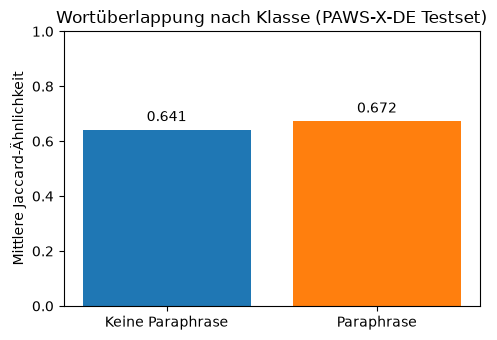

In [8]:
# Visualisierung der mittleren Jaccard-Ähnlichkeit nach Klasse

fig, ax = plt.subplots(figsize=(5, 3.5))
balken = ax.bar(mittelwerte.index, mittelwerte.values, color=["C0", "C1"])
ax.bar_label(balken, fmt="%.3f", padding=4)
ax.set_ylabel("Mittlere Jaccard-Ähnlichkeit")
ax.set_ylim(0, 1)
ax.set_title("Wortüberlappung nach Klasse (PAWS-X-DE Testset)")
plt.tight_layout()
plt.savefig(ERGEBNIS_FIGUREN_PFAD / "jaccard_nach_klasse.png", dpi=150)
plt.show()

**Abbildung 1:** Berechnung der Wortüberlappung nach Klasse auf dem deutschen PAWS-X-Testset (Yang et al., 2019)

Die beiden Balken liegen nah beieinander: "Keine Paraphrase"-Paare haben im Mittel eine fast ebenso hohe Wortüberlappung wie tatsächliche Paraphrasen. Ein Modell, das ausschließlich auf Wortidentität basiert, hat hier strukturell kaum eine Chance, beide Klassen zu trennen. Das ist die Kernschwierigkeit, die den Rest dieses Notebooks motiviert und in Abschnitt 5.1 direkt sichtbar wird.

## 3. Theoretischer Hintergrund

In diesem Abschnitt werden die Methoden die in Abschnitt 5 implementiert und verglichen werden kurz erläutert und zusammengefasst.

### 3.1 Klassische, lexikalische Verfahren

**Wortüberlappung (Jaccard-Ähnlichkeit)** 

Eine einfache Methode, bei der beide Sätze (nach Kleinschreibung, Satzzeichenentfernung usw., siehe Abschnitt 2.3) als Mengen ihrer Wörter $A$ und $B$ betrachtet werden und die Jaccard-Ähnlichkeit folgendermaßen berechnet wird:

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

Ein Schwellenwert $\theta$ entscheidet dann über **Paraphrase/keine Paraphrase**: $\hat{y} = \mathbb{1}[J(A,B) \geq \theta]$. Der Schwellenwert wird auf dem Validierungsset per F1-Score bestimmt (siehe Implementierung in Abschnitt 5.1). Diese Methode dient hier als **untere Baseline**. Jedes andere Modell sollte sie deutlich übertreffen, sonst lohnt sich der zusätzliche Aufwand nicht.

**TF-IDF** 

Jeder Satz wird über ein gemeinsames Vokabular (Unigramme und Bigramme, gefittet auf den Trainingsdaten) in einen hochdimensionalen, dünn besetzten Vektor überführt, dessen Einträge nicht nur "Wort kommt vor/nicht vor" codieren, sondern wie charakteristisch ein Wort für den jeweiligen Satz ist. Für ein Wort bzw. Bigramm $t$ in einem Dokument $d$ innerhalb eines Korpus mit $N$ Dokumenten gilt (in der von scikit-learn verwendeten, geglätteten Form, Pedregosa et al., 2011):

$$\text{tf}(t,d) = \text{Anzahl von } t \text{ in } d \qquad \text{idf}(t) = \ln\!\left(\frac{1+N}{1+\text{df}(t)}\right) + 1 \qquad \text{tf-idf}(t,d) = \text{tf}(t,d) \cdot \text{idf}(t)$$

wobei $\text{df}(t)$ die Anzahl der Dokumente ist, die $t$ enthalten. Wörter, die in vielen Dokumenten vorkommen (z.B. Funktionswörter wie "und", "der"), erhalten einen niedrigen IDF-Wert und tragen kaum zur Unterscheidung bei. Dagegen Wörter, die nur in wenigen Dokumenten, dafür dort aber häufig auftreten, erhalten hohe Gewichte. Die resultierenden TF-IDF-Vektoren werden zusätzlich auf Einheitslänge (L2-Norm) normalisiert.

Aus beiden Satzvektoren plus ihrer Kosinusähnlichkeit wird ein gemeinsamer Merkmalsvektor gebildet: `[TF-IDF(Satz1), TF-IDF(Satz2), Kosinusähnlichkeit]`. Dieser Merkmalsvektor wird hier mit zwei unterschiedlichen linearen Klassifikatoren kombiniert (implementiert über scikit-learn, Pedregosa et al., 2011):

- **Logistische Regression** modelliert die Wahrscheinlichkeit $P(y=1\mid x) = \sigma(w^\top x + b)$ über die Sigmoid-Funktion $\sigma(z) = 1/(1+e^{-z})$ und wird durch Minimierung der Log-Loss (negative Log-Likelihood) trainiert. Sie liefert dadurch direkt eine kalibrierte Wahrscheinlichkeit.
- **Linear SVM** (`LinearSVC`) sucht stattdessen die Trenn-Hyperebene $w^\top x + b = 0$, die den Rand (margin) zu den nächstgelegenen Trainingspunkten beider Klassen maximiert, trainiert über die Hinge-Loss. Sie optimiert also nicht direkt für Wahrscheinlichkeiten, sondern für eine möglichst robuste Trennung. Praktisch relevant: `LinearSVC` liefert deshalb standardmäßig keine Vorhersagewahrscheinlichkeit (`predict_proba`), sondern nur einen vorzeichenbehafteten Abstand zur Trennebene (`decision_function`), der als Ersatz-Score verwendet wird.

Der Unterschied zur Jaccard-Baseline besteht darin, dass beide TF-IDF-Modelle Gewichte für einzelne Wörter/Bigramme aus den Trainingsdaten **lernen**, anstatt nur einen einzelnen globalen Schwellenwert zu setzen. Es bleibt aber, wie die Jaccard-Baseline, eine **Bag-of-Words-Methode**: Die Position eines Wortes im Satz geht nicht in die Merkmale ein. "Hund beißt Mann" und "Mann beißt Hund" erzeugen (bis auf die Bigramme an der Vertauschungsstelle) sehr ähnliche Merkmalsvektoren.

### 3.2 Kontextuelle Sprachmodelle: Transformer und BERT

Bag-of-Words-Methoden repräsentieren jedes Wort unabhängig von seinem Kontext. Das Wort "Bank" erhält immer denselben Vektor, egal ob im Satz von einer Sitzbank oder einem Geldinstitut die Rede ist. Bei Transformer-Modellen wie **BERT** (*Bidirectional Encoder Representations from Transformers*, Devlin et al., 2019) ist das anders. Dessen  Architektur basiert vollständig auf dem **Self-Attention**-Mechanismus, ohne rekurrente oder Faltungsschichten.

**Self-Attention** berechnet für jedes Token drei Vektoren (Query $Q$, Key $K$, Value $V$) als gelernte lineare Projektionen der Eingabe und gewichtet dann jeden Wert danach, wie gut Query und Key zueinander passen:

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Dadurch kann jedes Wort direkt gewichten, wie relevant jedes andere Wort im selben Kontext für seine Repräsentation ist, unabhängig von der Distanz zwischen beiden Wörtern im Satz (im Gegensatz zu rekurrenten Netzen, bei denen weit entfernte Wörter über viele Zwischenschritte "weitergereicht" werden müssen). "Multi-Head"-Attention wiederholt diese Berechnung mehrfach parallel mit unterschiedlichen gelernten Projektionen, damit unterschiedliche Attention-Köpfe unterschiedliche Arten von Beziehungen erfassen können (z.B. syntaktische vs. semantische Nähe). `bert-base` (wie das hier verwendete `bert-base-german-cased`) stapelt 12 solcher Attention-Blöcke mit 768-dimensionalen versteckten Repräsentationen und 12 Attention-Köpfen pro Block (ca. 110 Mio. Parameter); `xlm-roberta-base` (Abschnitt 3.4) verwendet dieselbe Blockanzahl und Breite, aber ein deutlich größeres Vokabular.

Eingaben werden zuvor in Sub-Wort-Einheiten zerlegt (BERT: ca. 30.000 Einheiten) statt in ganze Wörter. Dadurch bleiben auch seltene oder zusammengesetzte Wörter darstellbar, indem sie in bekannte Wortstücke zerlegt werden, ohne dass ein unbegrenzt großes Vokabular nötig wäre.

Vortrainiert wird BERT mit dem Ziel des **Masked Language Modeling**. Zufällig maskierte Wörter müssen aus ihrem beidseitigen Kontext vorhergesagt werden. Das ursprüngliche BERT-Paper kombiniert dies mit einem zweiten Vortrainingsziel, der **Next Sentence Prediction** (Vorhersage, ob zwei Textabschnitte im Original tatsächlich aufeinanderfolgten). RoBERTa (Liu et al., 2019) zeigte später, dass dieses zweite Ziel verzichtbar ist. Mit längerem Training auf mehr Daten und größeren Batches, aber ohne Next-Sentence-Prediction, lässt sich dieselbe Architektur weiter verbessern. `xlm-roberta-base` (Abschnitt 3.4) baut auf genau dieser RoBERTa-Vortrainingsvariante auf.

Für die konkrete Aufgabe der Paraphrasenerkennung wird das vortrainierte BERT-Modell anschließend **feinabgestimmt** (Fine-Tuning). Ein zusätzlicher Klassifikationskopf (eine einzelne lineare Schicht) wird auf der Repräsentation des `[CLS]`-Tokens aufgesetzt und mit Sigmoid-Aktivierung sowie Binary-Cross-Entropy-Loss trainiert.  Alle Gewichte des Modells werden dabei mit einer kleinen Lernrate weiter an die Zielaufgabe angepasst. Im Gegensatz zu den TF-IDF-Modellen wird hier also nicht auf festen Merkmalen ein separater Klassifikator trainiert, sondern die Repräsentation selbst lernt mit.

### 3.3 Architekturen für Satzpaare: Bi-Encoder vs. Cross-Encoder

Für Aufgaben mit **zwei** Eingabesätzen gibt es zwei grundsätzlich unterschiedliche Möglichkeiten, ein Transformer-Modell wie BERT einzusetzen (vgl. Reimers & Gurevych, 2019):

- **Bi-Encoder (Siamese-Architektur):** Jeder Satz wird **unabhängig** vom anderen durch dasselbe Modell geschickt und zu einem einzigen Vektor gepoolt ("Sentence Embedding"). Erst danach werden beide Vektoren verglichen (z.B. Kosinusähnlichkeit oder ein kleiner Klassifikator auf der Kombination beider Vektoren). Der Vorteil ist, dass sich die Embeddings wiederverwenden/cachen lassen, was essenziell ist wenn z.B.: ein Satz gegen Millionen andere verglichen werden soll (Retrieval). Der Nachteil ist,  dass die beiden Sätze sich beim Encodieren nie gegenseitig "sehen". Dadurch gehen wortweise Interaktionen zwischen den Sätzen beim Pooling zu einem einzigen Vektor verloren.

- **Cross-Encoder:** Beide Sätze werden gemeinsam als eine einzige Sequenz `[CLS] Satz 1 [SEP] Satz 2 [SEP]` in das Modell gegeben. Self-Attention kann dadurch direkt jedes Wort aus Satz 1 mit jedem Wort aus Satz 2 in Beziehung setzen, bevor überhaupt eine Klassifikationsentscheidung getroffen wird. Der Nachteil ist, dass für jedes neue Satzpaar ein komplett neuer Forward-Pass gerechnet werden muss. Nichts lässt sich vorab cachen, was den Ansatz für Suche über große Dokumentmengen unpraktikabel macht, für die feste Klassifikationsaufgabe hier aber unproblematisch ist.

 Die für die Paraphrasenerkennung verwendeten Transformer Modelle lassen sich in diese Kategorien einordnen. Modell 4 (Sentence Embeddings) ist ein Bi-Encoder, die Modelle 5 und 6 (Cross-Encoder) verarbeiten beide Sätze gemeinsam. Für ein Konstruktionsprinzip wie PAWS-X, bei dem gerade die Anordnung von Wörtern/Entitäten über das Label entscheidet, ist genau dieser Unterschied entscheidend. Die folgende Abbildung stellt beide Architekturen schematisch gegenüber. 


![Abbildung 2](../results/figures/bi_cross_encoder.png)
**Abbildung 2:** Vergleich der Encoder Konzepte nach Reimers & Gurevych (2019, Fig. 1) bzw. [sbert.net](https://www.sbert.net/examples/cross_encoder/applications/README.html)

### 3.4 Mehrsprachige vs. monolinguale Sprachmodelle

Modell 5 und Modell 6 verwenden dieselbe Cross-Encoder-Architektur, aber unterschiedliche vortrainierte Backbones: `google-bert/bert-base-german-cased` ist **monolingual** (ausschließlich auf deutschen Texten vortrainiert), `xlm-roberta-base` (Conneau et al., 2020) ist **mehrsprachig** und deckt gleichzeitig ca. 100 Sprachen mit einem gemeinsamen Vokabular und gemeinsamen Modellgewichten ab.

Mehrsprachige Modelle haben den offensichtlichen Vorteil, dass ein einziges Modell für viele Sprachen verwendet und Wissen zwischen den Sprachen transferiert werden kann (z.B.: Zero-Shot-Transfer). Der Preis dafür ist ein deutlich größeres Vokabular (bei XLM-R ca. 250.000 Subword-Einheiten für 100 Sprachen, gegenüber ca. 30.000 bei einem monolingualen deutschen BERT), was die Anzahl der Modellparameter spürbar erhöht. Bei sonst vergleichbarer Architektur hat `xlm-roberta-base` ca. 2.55-mal so viele Parameter wie `bert-base-german-cased`. Ob sich dieser Mehraufwand für eine rein deutsche Aufgabe lohnt, obwohl 99% der mehrsprachigen Kapazität des Modells hier ungenutzt bleiben, ist eine der Fragen, die Abschnitt 5.4 bearbeitet wurde.

### 3.5 Evaluationsmetriken

Bei binärer Klassifikation lassen sich Vorhersagen in vier Fälle einteilen: **True Positives** (TP), **False Positives** (FP), **True Negatives** (TN), **False Negatives** (FN) (bezogen auf die Klasse "Paraphrase"). Daraus ergeben sich die in diesem Notebook durchgehend verwendeten Metriken:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} \qquad \text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN} \qquad F_1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

**Accuracy** allein reicht nicht aus, weil ein Modell das (wie in Abschnitt 5.1) fast immer "Paraphrase" vorhersagt, allein durch die Klassenverteilung eine hohe Recall/niedrige Precision-Kombination erzeugen kann, ohne inhaltlich viel gelernt zu haben. **Precision**, **Recall** und **F1** zusammen zeigen ein Ungleichgewicht deutlicher als **Accuracy** allein. Deshalb werden im gesamten Notebook alle vier Metriken erhoben (implementiert über scikit-learn, Pedregosa et al., 2011) und in Abschnitt 5.6 zusätzlich zur reinen Accuracy-Tabelle visualisiert. Ergänzend zeigt die **Konfusionsmatrix** (Abschnitt 5.6) direkt, welche der vier Fallgruppen wie oft auftreten, statt sie zu einer einzelnen Kennzahl zu verdichten.

## 4. Stand der Technik

PAWS-X wird in der Literatur nicht über ein einzelnes, kontinuierlich gepflegtes Leaderboard verglichen wie z.B.: GLUE oder SQuAD. Die Seite [paperswithcode.com/dataset/paws-x](https://paperswithcode.com/dataset/paws-x) leitet direkt auf die Hugging-Face-Datensatzseite weiter, ohne eigene Rangliste. Die relevantesten Vergleichszahlen stammen daher aus dem Originalpaper (Yang et al., 2019) sowie aus dem XTREME-Benchmark (Hu et al., 2020), der PAWS-X als eine von neun Aufgaben zur Bewertung mehrsprachiger vortrainierter Modelle (u.a. mBERT, XLM-R) verwendet.

Yang et al. (2019) berichten in ihrer Tabelle 4 folgende Test-Accuracy-Werte für den **deutschen** Datensatz, je nach Trainingsstrategie:

| Modell | Trainingsstrategie | Accuracy (Deutsch) |
| --- | --- | ---: |
| Bag-of-Words | Translate-Train | 50.2% |
| ESIM | Translate-Train | 63.7% |
| (m)BERT | Zero-Shot (nur Englisch trainiert) | 82.2% |
| (m)BERT | **Translate-Train** (auf maschinell übersetzten deutschen Daten) | **85.3%** |
| (m)BERT | Translate-Test (Testdaten zur Inferenz ins Englische übersetzt) | 88.4% |
| (m)BERT | Merged (Englisch + übersetzte Daten kombiniert) | 89.2% |

Die **Translate-Train**-Accuracy ist für die vorliegende Arbeit der sinnvollste Vergleichspunkt, da wie in Abschnitt 5 direkt auf dem maschinell übersetzten deutschen PAWS-X-Trainingssplit, ohne zusätzliche Übersetzungstricks zur Inferenzzeit oder zusätzliche englische Trainingsdaten trainiert wurde. Der Unterschied zum hier verwendeten Aufbau ist, dass von Yang et al. ein **multilinguales** BERT (mBERT) verwendet wurde. In Abschnitt 5.4 werden dagegen explizit ein **monolingual deutsches** BERT und ein **mehrsprachiges** XLM-RoBERTa verglichen.

Ein State-of-the-Art-Cross-Encoder-Ansatz auf dem deutschen PAWS-X-Datensatz sollte sich also im Bereich von ca. **85–89% Accuracy** bewegen, klassische Bag-of-Words-Methoden dagegen kaum über die Mehrheitsklassen-Baseline hinauskommen. Der direkte quantitative Vergleich mit der eigenen Lösung ist in Abschnitt 7.1 zu finden.

## 5. Implementierung und Ergebnisse

Alle sechs Modelle implementieren dieselbe Schnittstelle (`BasisModell` aus `src/pawsx_project/models/base.py`) und laufen über dieselbe Pipeline-Funktion `fuehre_experiment_durch()`, die intern `fit()` auf den Trainingsdaten und anschließend eine einheitliche Evaluation (Accuracy, Precision, Recall, F1) auf dem Testset aufruft und die Predictions unter `results/predictions/` speichert. Dadurch sind alle Modelle direkt vergleichbar und die Fehleranalyse in Abschnitt 6 kann modellübergreifend auf denselben Testfällen durchgeführt werden.

### 5.1 Modell 1: Wortüberlappung (Baseline)

Direkte Umsetzung der Jaccard-Ähnlichkeit aus Abschnitt 3.1. Der Klassifikations-Schwellenwert wird auf dem Validierungsset per F1-Score bestimmt.

**Hypothese 1:** Ein reines Wortüberlappungsmaß sollte nur begrenzte Leistung erzielen, da Wortreihenfolge und Satzstruktur ignoriert werden.

In [9]:
# Training und Evaluierung des Jaccard Baseline-Modells auf Trainings-, Validierungs- und Testdaten

from pawsx_project.models.lexical import JaccardModell

jaccard_modell = JaccardModell()
ergebnis_jaccard = fuehre_experiment_durch(jaccard_modell, train_df, val_df, test_df)

mehrheitsklasse_anteil = test_df["label"].value_counts(normalize=True).max()
print(f"Gelernter Schwellenwert: {jaccard_modell._schwelle:.3f}")
print(f"Zum Vergleich, Mehrheitsklassen-Baseline Accuracy: {mehrheitsklasse_anteil:.3f}")
ergebnis_jaccard

Gelernter Schwellenwert: 0.111
Zum Vergleich, Mehrheitsklassen-Baseline Accuracy: 0.552


{'Modell': 'Wortüberlappung (Jaccard)',
 'Accuracy': 0.46,
 'Precision': 0.45297407219115404,
 'Recall': 0.9955307262569832,
 'F1': 0.6226415094339622,
 'Trainingszeit (s)': 0.45236210000075516}

**Beobachtung:** Wie in Abschnitt 2.4 beschrieben, landet die Baseline nahe an oder sogar unter der Mehrheitsklassen-Baseline. Der gelernte Schwellenwert ist sehr niedrig, sodass das Modell fast immer **"Paraphrase"** vorhersagt (hoher Recall, aber niedrige Precision). Das ist ein gutes Beispiel dafür, warum eine reine Accuracy-Betrachtung nicht sinnvoll ist. Zugleich bestätigt sich  **Hypothese 1** deutlich, da ein reines Überlappungsmaß die von PAWS-X gezielt konstruierten Gegenbeispiele nicht trennen kann.

### 5.2 Modell 2/3: TF-IDF + Logistische Regression / Linear SVM

Ein Merkmalsvektor pro Satzpaar: `[TF-IDF(Satz 1), TF-IDF(Satz 2), Kosinusähnlichkeit]`, wie in Abschnitt 3.1 beschrieben.

**Hypothese 2:** TF-IDF-basierte ML-Modelle sollten die reine Wortüberlappung übertreffen (sie *lernen* Gewichte statt nur einen Schwellenwert zu setzen), aber weiterhin an Satzpaaren mit hoher lexikalischer Überlappung und unterschiedlicher Bedeutung scheitern, da die zugrundeliegenden Merkmale weiterhin Bag-of-Words sind.

In [10]:
# Training und Evaluierung der TF-IDF Modelle (Logistische Regression und Linear SVM) auf Trainings-, Validierungs- und Testdaten

from pawsx_project.models.tfidf import TfidfLinearSVM, TfidfLogistischeRegression

tfidf_lr_modell = TfidfLogistischeRegression()
tfidf_svm_modell = TfidfLinearSVM()
ergebnisse_tfidf = [
    fuehre_experiment_durch(tfidf_lr_modell, train_df, val_df, test_df),
    fuehre_experiment_durch(tfidf_svm_modell, train_df, val_df, test_df),
]
pd.DataFrame(ergebnisse_tfidf)

,Modell,Accuracy,Precision,Recall,F1,Trainingszeit (s)
0,TF-IDF + Logistische Regression,0.5785,0.558296,0.278212,0.371365,7.282124
1,TF-IDF + Linear SVM,0.5610,0.513471,0.362011,0.424640,8.496308


**Beobachtung:** Beide Varianten übertreffen die Jaccard-Baseline klar und bestätigen damit **Hypothese 2**. Sie bleiben aber nur wenige Prozentpunkte über der Mehrheitsklassen-Baseline. Echtes Lernen hilft, aber die zugrundeliegenden Bag-of-Words-Merkmale erfassen weiterhin primär nur **welche** Wörter vorkommen und nicht **wie** sie angeordnet sind.

### 5.3 Modell 4: Sentence Embeddings (Bi-Encoder)

Beide Sätze werden über einen vortrainierten, auf Paraphrasen-/STS-Aufgaben optimierten Sentence-Transformer (`paraphrase-multilingual-mpnet-base-v2`, Reimers & Gurevych, 2019) in dichte Embeddings überführt (Bi-Encoder-Architektur, siehe Abschnitt 3.3). Der Merkmalsvektor: `[Kosinusähnlichkeit, |Embedding1 − Embedding2|, Embedding1 ⊙ Embedding2]` wird mittels Logistischer Regression klassifiziert.

**Hypothese 3:** Semantische Embeddings sollten TF-IDF übertreffen, da sie gezielt für Bedeutungsähnlichkeit statt reiner Wortidentität trainiert wurden.

In [11]:
# Training und Evaluierung des Sentence Transformer Modells auf Trainings-, Validierungs- und Testdaten

from pawsx_project.models.sentence_transformer import SentenceTransformerModell

st_modell = SentenceTransformerModell()
ergebnis_st = fuehre_experiment_durch(st_modell, train_df, val_df, test_df)
ergebnis_st

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

{'Modell': 'Sentence Transformer + Logistische Regression',
 'Accuracy': 0.5825,
 'Precision': 0.5761421319796954,
 'Recall': 0.2536312849162011,
 'F1': 0.352211016291699,
 'Trainingszeit (s)': 168.7431575999999}

**Beobachtung:** Überraschend wenig Verbesserung gegenüber TF-IDF, obwohl das Modell explizit für Paraphrasenerkennung trainiert wurde. **Hypothese 3** wird damit **nicht** bestätigt. Das passt zur Bi-Encoder-Einschränkung aus Abschnitt 3.3, da jeder Satz getrennt zu einem einzigen Vektor gepoolt wird, gehen genau die wortreihenfolge-/entitätspositionsabhängigen Unterschiede verloren, für die PAWS-X konstruiert wurde. "A verklagte B" und "B verklagte A" landen im Embedding-Raum sehr nah beieinander.

### 5.4 Modell 5/6: Cross-Encoder (BERT und XLM-RoBERTa)

Beide Sätze werden gemeinsam als `[CLS] Satz1 [SEP] Satz2 [SEP]` durch ein vortrainiertes Modell geschickt und direkt für binäre Klassifikation feinabgestimmt (Cross-Encoder-Architektur, siehe Abschnitt 3.2/3.3). Verglichen werden zwei Backbones bei sonst identischen Hyperparametern (2 Epochen, Batch-Size 16, Lernrate 2e-5, `max_length=128`):

- **Modell 5:** `google-bert/bert-base-german-cased`, monolinguales Modell für deutsche Sprache. 
- **Modell 6:** `xlm-roberta-base` (Conneau et al., 2020), mehrsprachiges Modell mit ca. 2.55-mal so vielen Parametern wie `google-bert/bert-base-german-cased`.

**Hypothese 4:** Ein Cross-Encoder sollte alle vorherigen Modelle übertreffen, weil er als einziger beide Sätze gemeinsam mit gegenseitiger Attention verarbeitet statt sie getrennt zu einem Vektor zu komprimieren.

**Hypothese 5:** Das stärkere, aber deutlich teurere mehrsprachige Backbone (Modell 6) verbessert das Ergebnis weiter. Fraglich ist, ob der Genauigkeitsgewinn den erheblichen Mehraufwand an Trainingszeit rechtfertigt.

**Hinweis:** Modell 5 trainiert mit den aktuellen Einstellungen ca. 15 Minuten auf einer NVIDIA RTX 3060 (deutlich länger auf CPU), Modell 6 ca. 3 Stunden. Beide Modelle speichern nach dem Training automatisch einen Checkpoint unter `results/models/`, welcher bei erneuter Ausführung geladen wird anstatt neu zu trainieren.

In [12]:
# Training und Evaluierung des Cross Encoder Modells auf Trainings-, Validierungs- und Testdaten

from pawsx_project.models.cross_encoder import CrossEncoderModell

ce_modell = CrossEncoderModell(
    epochen=2,
    checkpoint_pfad=ERGEBNIS_MODELLE_PFAD / "cross_encoder_bert",
)
ergebnis_ce = fuehre_experiment_durch(ce_modell, train_df, val_df, test_df)
ergebnis_ce

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'Modell': 'Transformer Cross-Encoder',
 'Accuracy': 0.8535,
 'Precision': 0.822961373390558,
 'Recall': 0.8569832402234637,
 'F1': 0.8396278051450465,
 'Trainingszeit (s)': 900.0}

**Zwischenschritt: GPU-Speicher freigeben** Die verfügbare Laptop-GPU hat nur 6GB VRAM. Modell 6 (XLM-R) ist mit 2.55-mal so vielen Parametern deutlich speicherhungriger. Die beiden Cross-Encoder gleichzeitig im VRAM zu halten, waf auf der verwendeten Hardware nicht praktikabel. Deshalb wird Modell 5 hier explizit auf die CPU verschoben, bevor Modell 6 geladen wird (dieser Schritt ist eventuell nicht notwenig auf besserer Hardware).

In [13]:
# Freigabe des VRAMs, nachdem das Cross Encoder Modell auf CPU verschoben wurde

import gc
import torch

if torch.cuda.is_available():
    ce_modell._modell.to("cpu")
    gc.collect()
    torch.cuda.empty_cache()
    print("BERT-Cross-Encoder von GPU auf CPU verschoben, VRAM freigegeben.")

BERT-Cross-Encoder von GPU auf CPU verschoben, VRAM freigegeben.


In [14]:
# Training und Evaluierung des Cross Encoder Modells mit XLM-RoBERTa auf Trainings-, Validierungs- und Testdaten

from pawsx_project.config import CROSS_ENCODER_BASISMODELL_STARK

ce_xlmr_modell = CrossEncoderModell(
    modellname=CROSS_ENCODER_BASISMODELL_STARK,
    epochen=2,
    anzeigename="Transformer Cross-Encoder (XLM-RoBERTa)",
    checkpoint_pfad=ERGEBNIS_MODELLE_PFAD / "cross_encoder_xlmr",
)
ergebnis_ce_xlmr = fuehre_experiment_durch(ce_xlmr_modell, train_df, val_df, test_df)
pd.DataFrame([ergebnis_ce, ergebnis_ce_xlmr])

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,Modell,Accuracy,Precision,Recall,F1,Trainingszeit (s)
0,Transformer Cross-Encoder,0.8535,0.822961,0.856983,0.839628,900.0
1,Transformer Cross-Encoder (XLM-RoBERTa),0.8660,0.836735,0.870391,0.853231,10800.0


**Beobachtung:** Beide Cross-Encoder übertreffen alle vorherigen Modelle deutlich und bestätigen **Hypothese 4** klar. Gemeinsames Verarbeiten beider Sätze mit gegenseitiger Attention ist der entscheidende architektonische Unterschied, nicht Modellgröße oder Vortrainingsziel. Das stärkere XLM-R-Backbone (Modell 6) verbessert das Ergebnis nochmals gegenüber Modell 5, allerdings für einen Trainingsaufwand, der ca. 12-mal länger dauert (3h vs. 15min) als der Genauigkeitsgewinn zunächst vermuten lässt. **Hypothese 5** bestätigt sich damit nur teilweise, denn das Modell wird tatsächlich besser, aber der Aufwand steht in keinem proportionalen Verhältnis zum Gewinn.

### 5.5 Reihenfolge-Symmetrie bei beiden Cross-Encodern

Die tiefergehende Fehleranalyse (siehe Abschnitt 6.2) zeigt unter anderem Fälle, in denen der Cross-Encoder eine kommutative Umformulierung ("A oder B" vs. "B oder A") fälschlich als Bedeutungsänderung wertet. Die Eingabe hat die Form `[CLS] Satz1 [SEP] Satz2 [SEP]`. Architektonisch gibt es keinen Grund, warum das Modell bei vertauschter Reihenfolge (`Satz2, Satz1`) exakt denselben Score liefern sollte, obwohl "ist Paraphrase von" eine symmetrische Relation ist (wenn A eine Paraphrase von B ist, ist B auch eine Paraphrase von A).

**Idee:** Für jedes Testpaar beide Reihenfolgen durch das bereits trainierte Modell schicken und die beiden Scores mitteln (Test-Time-Augmentation durch Symmetrisierung, ohne erneutes Training). Falls das Modell tatsächlich inkonsistent auf Reihenfolge reagiert, sollte die gemittelte Vorhersage robuster sein. Diese Symmetrisierung erfordert **kein erneutes Training**, sondern nur einen zweiten Inferenzdurchlauf mit vertauschten Spalten auf dem bereits fertig feinabgestimmten Modell. Das dauert für beide Modelle nur Sekunden bis wenige Minuten.

Geprüft wird zunächst Modell 6 (XLM-R), da es nach Abschnitt 5.4 noch auf der GPU liegt. Anschließend werden die Modelle für Modell 5 (BERT) getauscht.

In [15]:
# Reihenfolge der Sätze in den Testdaten vertauschen und Vorhersagen des Cross Encoder Modells mit XLM-RoBERTa analysieren

from pawsx_project.models.cross_encoder import predict_proba_beide_richtungen

score_normal_xlmr, score_vertauscht_xlmr = predict_proba_beide_richtungen(ce_xlmr_modell, test_df)

flip_rate_xlmr = ((score_normal_xlmr >= 0.5).astype(int) != (score_vertauscht_xlmr >= 0.5).astype(int)).mean()
print(f"XLM-R -- Anteil Testfaelle, bei denen vertauschte Reihenfolge die Vorhersage kippt: {flip_rate_xlmr:.1%}")
print(f"XLM-R -- Korrelation normal vs. vertauscht: {np.corrcoef(score_normal_xlmr, score_vertauscht_xlmr)[0, 1]:.3f}")

XLM-R -- Anteil Testfaelle, bei denen vertauschte Reihenfolge die Vorhersage kippt: 4.3%
XLM-R -- Korrelation normal vs. vertauscht: 0.965


In [16]:
# Berechnung der symmetrisierten Vorhersagen und Evaluierung der Scores des Cross Encoder Modells mit XLM-RoBERTa

from pawsx_project.evaluation import evaluiere_scores

score_symmetrisch_xlmr = (score_normal_xlmr + score_vertauscht_xlmr) / 2
ergebnis_symmetrisch_xlmr = evaluiere_scores(
    "Cross-Encoder (XLM-R, symmetrisiert)", test_df["label"].to_numpy(), score_symmetrisch_xlmr
)

pd.DataFrame([ergebnis_ce_xlmr, ergebnis_symmetrisch_xlmr])


,Modell,Accuracy,Precision,Recall,F1,Trainingszeit (s)
0,Transformer Cross-Encoder (XLM-RoBERTa),0.866,0.836735,0.870391,0.853231,10800.0
1,"Cross-Encoder (XLM-R, symmetrisiert)",0.871,0.844324,0.872626,0.858242,NaN


**Zwischenergebnis (XLM-R):** Auch beim größeren, mehrsprachigen Backbone zeigt sich eine relevante Reihenfolge-Sensitivität. Bei **4.3%** der Testpaare kippt die vertauschte Satzreihenfolge die binäre Vorhersage, und die Korrelation der Rohscores beider Richtungen liegt mit **0.965** spürbar unter 1.0. Die symmetrisierte Vorhersage verbessert das Ergebnis gegenüber der Rohvorhersage von 86.6% auf **87.1%** Accuracy (F1 von: 0.853 auf 0.858), wie der Tabellenvergleich oben zeigt. Das ist ein etwas kleinerer Effekt als bei BERT (siehe unten). Passend dazu hat das XLM-R Modell ebenfalls eine etwas niedrigere Flip-Rate, da das stärkere Backbone schon von sich aus etwas konsistenter gegenüber der Reihenfolge ist. Es profitiert aber immer noch messbar von der Symmetrisierung.

**GPU-Speicher tauschen:** Um denselben Test für Modell 5 (BERT) durchzuführen, muss es zurück auf die GPU geholt werden (siehe Abschnitt 5.4 zur VRAM-Begrenzung der Laptop-GPU). Daher wird Modell 6 zunächst wieder auf die CPU verschoben.


In [17]:
# Freigabe des VRAMs, nachdem das Cross Encoder Modell mit XLM-RoBERTa auf CPU verschoben wurde

if torch.cuda.is_available():
    ce_xlmr_modell._modell.to("cpu")
    ce_modell._modell.to("cuda")
    gc.collect()
    torch.cuda.empty_cache()
    print("XLM-R-Cross-Encoder auf CPU, BERT-Cross-Encoder zurueck auf GPU verschoben.")


XLM-R-Cross-Encoder auf CPU, BERT-Cross-Encoder zurueck auf GPU verschoben.


In [18]:
# Reihenfolge der Sätze in den Testdaten vertauschen und Vorhersagen des Cross Encoder Modells mit BERT analysieren

score_normal_bert, score_vertauscht_bert = predict_proba_beide_richtungen(ce_modell, test_df)

flip_rate_bert = ((score_normal_bert >= 0.5).astype(int) != (score_vertauscht_bert >= 0.5).astype(int)).mean()
print(f"BERT -- Anteil Testfaelle, bei denen vertauschte Reihenfolge die Vorhersage kippt: {flip_rate_bert:.1%}")
print(f"BERT -- Korrelation normal vs. vertauscht: {np.corrcoef(score_normal_bert, score_vertauscht_bert)[0, 1]:.3f}")


BERT -- Anteil Testfaelle, bei denen vertauschte Reihenfolge die Vorhersage kippt: 6.5%
BERT -- Korrelation normal vs. vertauscht: 0.933


In [19]:
# Berechnung der symmetrisierten Vorhersagen und Evaluierung der Scores des Cross Encoder Modells mit BERT

score_symmetrisch_bert = (score_normal_bert + score_vertauscht_bert) / 2
ergebnis_symmetrisch_bert = evaluiere_scores(
    "Cross-Encoder (BERT, symmetrisiert)", test_df["label"].to_numpy(), score_symmetrisch_bert
)

pd.DataFrame([ergebnis_ce, ergebnis_symmetrisch_bert])


,Modell,Accuracy,Precision,Recall,F1,Trainingszeit (s)
0,Transformer Cross-Encoder,0.8535,0.822961,0.856983,0.839628,900.0
1,"Cross-Encoder (BERT, symmetrisiert)",0.8600,0.831001,0.862570,0.846491,NaN


**Ergebnis:** Bei beiden Cross-Encodern kippt ein relevanter Anteil der Testpaare die binäre Vorhersage allein durch Vertauschen der Satzreihenfolge (BERT: **6.5%**, XLM-R: **4.3%**). Die Korrelation der Rohscores beider Richtungen liegt jeweils spürbar unter 1.0 (BERT: 0.933, XLM-R: 0.965). Beide Modelle sind also messbar inkonsistent gegenüber einer Relation, die eigentlich symmetrisch sein sollte. Die symmetrisierte Vorhersage (Mittelwert beider Richtungen) verbessert das Ergebnis bei **beiden** Modellen:

| Modell | Accuracy (roh) | Accuracy (symmetrisiert) | F1 (roh) | F1 (symmetrisiert) |
| --- | ---: | ---: | ---: | ---: |
| BERT | 85.35% | **86.00%** | 0.8396 | **0.8465** |
| XLM-R | 86.60% | **87.10%** | 0.8532 | **0.8582** |

Eine kleine, aber praktisch kostenlose Verbesserung bei beiden Backbones: Sie erfordert kein erneutes Training, nur einen zweiten Inferenzdurchlauf mit vertauschten Spalten und eine Mittelung. Bemerkenswert ist, dass BERT etwas stärker profitiert (+0.65 Prozentpunkte Accuracy) als XLM-R (+0.50 Prozentpunkte). Das passt zu dessen höherer Flip-Rate. Das kleinere Modell reagiert also etwas empfindlicher auf die Eingabereihenfolge.

Der Effekt ist plausibel, da jedes Modell bei jedem einzelnen Fall potenziell etwas unterschiedlich (und teilweise falsch) auf die beiden Richtungen reagiert, glättet die Mittelung einen Teil des richtungsabhängigen Rauschens heraus, ohne dass echtes Signal verloren geht. Diese Idee ist bewusst orthogonal zu den fünf aufgestellten Hypothesen. Sie verbessert nicht das **Verständnis** der Modelle, sondern macht ihre ohnehin gelernte Entscheidung robuster gegenüber der Eingabereihenfolge, die für die Aufgabe irrelevant sein sollte. Für ein Modell ohne architektonische Garantie für Positions-Invarianz (im Gegensatz zu z.B.: explizit symmetrischen Siamese-Architekturen wie Modell 4) ist das ein einfacher, aber wirkungsvoller Kunstgriff, der sich hier zudem unabhängig von der Backbone-Größe als wirksam zeigt.


### 5.6 Gesamtvergleich

Alle Modelle im direkten Vergleich (inkl. beider symmetrisierten Varianten aus Abschnitt 5.5) tabellarisch mit allen vier Metriken und Trainingszeit, als Accuracy-Balkendiagramm, als gruppiertes Balkendiagramm über alle vier Metriken, als Trainingszeit-Vergleich und als Konfusionsmatrix (inkl. Prozentanteilen und F1) der beiden Cross-Encoder.


In [20]:
# Zusammenfassung der Ergebnisse aller Modelle in einer Tabelle

alle_ergebnisse = pd.DataFrame(
    [ergebnis_jaccard, ergebnisse_tfidf[0], ergebnisse_tfidf[1], ergebnis_st,
     ergebnis_ce, ergebnis_symmetrisch_bert, ergebnis_ce_xlmr, ergebnis_symmetrisch_xlmr]
).sort_values("Accuracy").reset_index(drop=True)

ERGEBNIS_METRIKEN_PFAD.mkdir(parents=True, exist_ok=True)
alle_ergebnisse.to_csv(ERGEBNIS_METRIKEN_PFAD / "modellvergleich.csv", index=False)
alle_ergebnisse

,Modell,Accuracy,Precision,Recall,F1,Trainingszeit (s)
0,Wortüberlappung (Jaccard),0.4600,0.452974,0.995531,0.622642,0.452362
1,TF-IDF + Linear SVM,0.5610,0.513471,0.362011,0.424640,8.496308
2,TF-IDF + Logistische Regression,0.5785,0.558296,0.278212,0.371365,7.282124
3,Sentence Transformer + Logistische Regression,0.5825,0.576142,0.253631,0.352211,168.743158
4,Transformer Cross-Encoder,0.8535,0.822961,0.856983,0.839628,900.000000
5,"Cross-Encoder (BERT, symmetrisiert)",0.8600,0.831001,0.862570,0.846491,NaN
6,Transformer Cross-Encoder (XLM-RoBERTa),0.8660,0.836735,0.870391,0.853231,10800.000000
7,"Cross-Encoder (XLM-R, symmetrisiert)",0.8710,0.844324,0.872626,0.858242,NaN


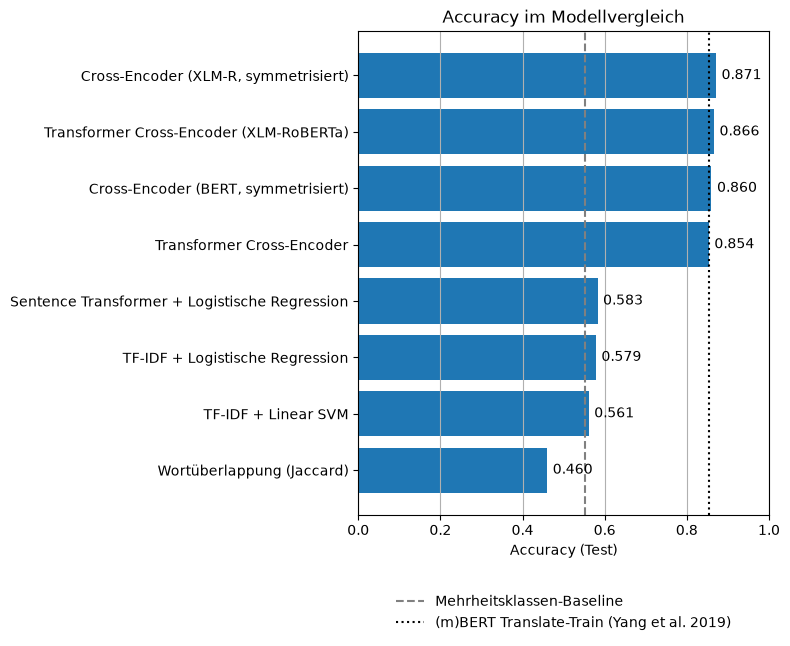

In [21]:
# Visualisierung der Accuracy aller Modelle im Vergleich

fig, ax = plt.subplots(figsize=(8, 6.5))
balken = ax.barh(alle_ergebnisse["Modell"], alle_ergebnisse["Accuracy"])
ax.bar_label(balken, fmt="%.3f", padding=4)
ax.axvline(mehrheitsklasse_anteil, color="gray", linestyle="--", label="Mehrheitsklassen-Baseline")
# (m)BERT, Translate-Train-Accuracy, Yang et al. (2019), Tabelle 4
mbert_literatur_accuracy = 0.853
ax.axvline(
    mbert_literatur_accuracy, color="black", linestyle=":",
    label="(m)BERT Translate-Train (Yang et al. 2019)",
)
ax.set_xlabel("Accuracy (Test)")
ax.set_xlim(0, 1)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), frameon=False)
ax.set_title("Accuracy im Modellvergleich")
ax.grid(axis="x")
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.savefig(ERGEBNIS_FIGUREN_PFAD / "modellvergleich_accuracy.png", dpi=150)
plt.show()

**Abbildung 3:** Test-Accuracy Auswertung aller trainierten Modelle und Vergleich mit Yang et al. (2019, Tabelle 4)

Die Leistung steigt weitgehend in der erwarteten Reihenfolge. Der Sprung von den Cross-Encodern zu allen anderen Modellen ist deutlich größer als die Unterschiede der ersten vier Modelle untereinander, ein starkes Indiz dafür, dass für PAWS-X das **gemeinsame** Verarbeiten beider Sätze der entscheidende Faktor ist, nicht Modellgröße oder Vortrainingsziel allein. Die gepunktete Linie markiert den in Abschnitt 4 diskutierten, fairsten Literatur-Vergleichspunkt ((m)BERT, Translate-Train, Yang et al. 2019: 85.3%). Alle vier Cross-Encoder-Varianten liegen auf oder über diesem publizierten Wert, obwohl das hier verwendete Setup mit einem monolingualen statt multilingualen BERT, nur 2 Trainingsepochen und ohne zusätzliche Übersetzungstricks auskommt.


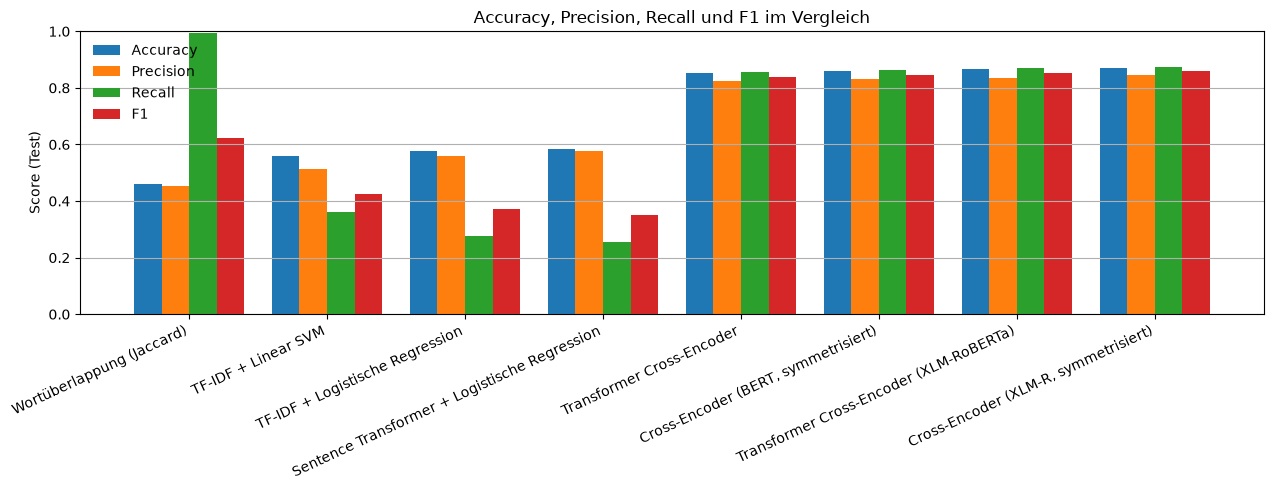

In [22]:
# Visualisierung der Accuracy, Precision, Recall und F1 aller Modelle im Vergleich

metriken = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(alle_ergebnisse))
breite = 0.2

fig, ax = plt.subplots(figsize=(13, 5))
for i, metrik in enumerate(metriken):
    ax.bar(x + i * breite, alle_ergebnisse[metrik], width=breite, label=metrik)
ax.set_xticks(x + breite * 1.5)
ax.set_xticklabels(alle_ergebnisse["Modell"], rotation=25, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Score (Test)")
ax.legend(frameon=False)
ax.set_title("Accuracy, Precision, Recall und F1 im Vergleich")
ax.grid(axis="y")
plt.tight_layout()
plt.savefig(ERGEBNIS_FIGUREN_PFAD / "modellvergleich_alle_metriken.png", dpi=150)
plt.show()


**Abbildung 4:** Test-Auswertung aller Modelle mit Accuracy, Precision, Recall und F1

In Abbildung 4 zeigt sich gut warum Accuracy allein in die Irre führen kann. Bei der Jaccard-Baseline klaffen Precision und Recall weit auseinander (sehr hoher Recall bei niedriger Precision, da das Modell fast immer "Paraphrase" vorhersagt), während sich bei den Cross-Encodern alle vier Metriken deutlich näher beieinander bewegen. Das ist ein Zeichen für eine ausgewogenere, nicht nur durch die Klassenverteilung erzwungene Entscheidung.

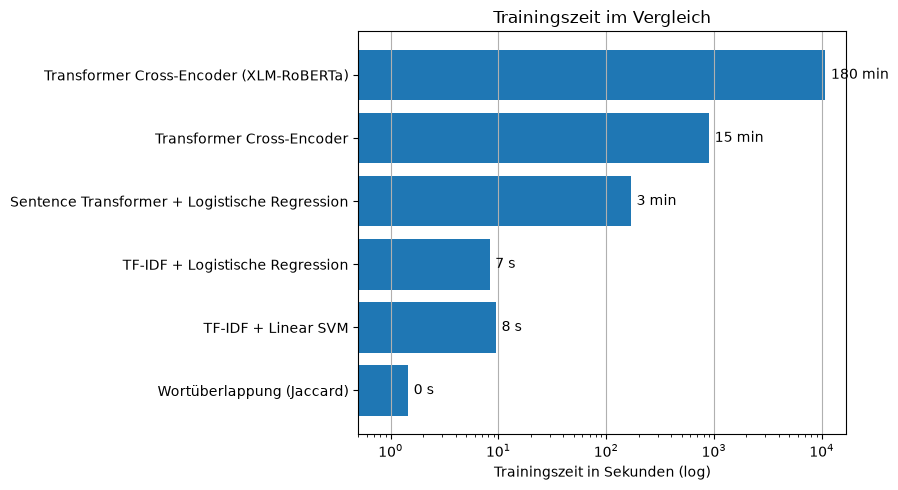

In [23]:
# Visualisierung der Trainingszeit aller Modelle im Vergleich

trainierte_modelle = alle_ergebnisse.dropna(subset=["Trainingszeit (s)"])
trainingszeit_label = [
    f"{s/60:.0f} min" if s >= 60 else f"{s:.0f} s"
    for s in trainierte_modelle["Trainingszeit (s)"]
]

fig, ax = plt.subplots(figsize=(9, 5))
balken = ax.barh(trainierte_modelle["Modell"], trainierte_modelle["Trainingszeit (s)"] + 1)
ax.bar_label(balken, labels=trainingszeit_label, padding=4)
ax.set_xscale("log")
ax.set_xlim(left=0.5)
ax.set_xlabel("Trainingszeit in Sekunden (log)")
ax.set_title("Trainingszeit im Vergleich")
ax.grid(axis="x")
plt.tight_layout()
plt.savefig(ERGEBNIS_FIGUREN_PFAD / "modellvergleich_trainingszeit.png", dpi=150)
plt.show()


**Abbildung 5:** gemessene bzw. (bei Cross-Encodern) beim ersten Training persistierte Trainingsdauer je Modell

Die Trainingszeit macht den mit Abstand größten praktischen Unterschied zwischen den verbleibenden Modellen sichtbar, den die reinen Genauigkeitswerte verschleiern. Die klassischen Modelle (Jaccard, TF-IDF, Sentence Transformer) trainieren in Sekunden, während die Cross-Encoder Minuten (BERT) bis Stunden (XLM-R) benötigen (siehe Abschnitt 5.4).


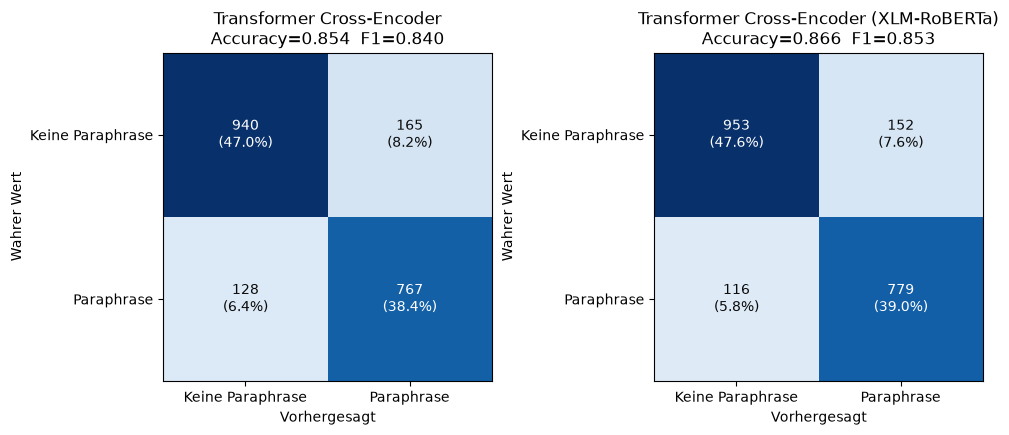

In [24]:
# Visualisierung der Konfusionsmatrizen der beiden Cross Encoder Modelle

fig, achsen = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, modell, ergebnis in zip(achsen, [ce_modell, ce_xlmr_modell], [ergebnis_ce, ergebnis_ce_xlmr]):
    y_pred = modell.predict(test_df)
    cm = confusion_matrix(test_df["label"], y_pred)
    cm_prozent = cm / cm.sum() * 100

    ax.imshow(cm, cmap="Blues", vmin=0)
    for i in range(2):
        for j in range(2):
            farbe_text = "white" if cm[i, j] > cm.max() * 0.6 else "#0b0b0b"
            ax.text(
                j, i, f"{cm[i, j]}\n({cm_prozent[i, j]:.1f}%)",
                ha="center", va="center", color=farbe_text, fontsize=10,
            )
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Keine Paraphrase", "Paraphrase"])
    ax.set_yticklabels(["Keine Paraphrase", "Paraphrase"])
    ax.set_xlabel("Vorhergesagt")
    ax.set_ylabel("Wahrer Wert")
    ax.set_title(f"{ergebnis['Modell']}\nAccuracy={ergebnis['Accuracy']:.3f}  F1={ergebnis['F1']:.3f}")

plt.tight_layout()
plt.savefig(ERGEBNIS_FIGUREN_PFAD / "konfusionsmatrizen_cross_encoder.png", dpi=150)
plt.show()


**Abbildung 6:** Konfusionsmatrizen für die Test-Vorhersagen beider Cross-Encoder-Modelle

Die Konfusionsmatrizen zeigen konkret, in welche Richtung die verbleibenden Fehler beider Modelle gehen (Falsch-Positive vs. Falsch-Negative), mit Prozentanteilen am gesamten Testset zusätzlich zu den absoluten Zahlen und mit F1 zusätzlich zur reinen Accuracy, da Accuracy allein (Abschnitt 3.5) die Verteilung der Fehler zwischen beiden Klassen nicht zeigt. Eine detailliertere Fehleranalyse folgt in Abschnitt 6.


### 5.7 Frei gewähltes Beispiel-Satzpaar

Alle sechs trainierten Modelle stehen weiterhin im Speicher und lassen sich direkt auf ein beliebiges, selbst gewähltes Satzpaar anwenden, unabhängig vom Testdatensatz. Das eignet sich besonders, um die in Abschnitt 5.5 gezeigte Reihenfolge-Sensitivität der Cross-Encoder an einem konkreten, leicht nachvollziehbaren Beispiel zu demonstrieren. Ein Satz und seine durch bloße Wortstellung veränderte, aber bedeutungsgleiche Umformulierung.

`eigener_satz1`/`eigener_satz2` können unten durch beliebigen eigenen Text ersetzt werden.


In [25]:
# Testen der Modelle mit eigenen Beispielsätzen

from pawsx_project.pipeline import werte_satzpaar_aus

alle_modelle = {
    "Jaccard (Wortüberlappung)": jaccard_modell,
    "TF-IDF + Logistische Regression": tfidf_lr_modell,
    "TF-IDF + Linear SVM": tfidf_svm_modell,
    "Sentence Transformer": st_modell,
    "Cross-Encoder (BERT)": ce_modell,
    "Cross-Encoder (XLM-R)": ce_xlmr_modell,
}


# Hier können eigene Beispielsätze eingegeben werden, um die Vorhersagen der trainierten Modelle zu testen

eigener_satz1 = "NLP ist der beste Kurs an der FH-SWF."
eigener_satz2 = "Der beste Kurs an der FH-SWF ist NLP."

werte_satzpaar_aus(alle_modelle, eigener_satz1, eigener_satz2)

,Modell,Vorhersage,Score
0,Jaccard (Wortüberlappung),Paraphrase,1.000000
1,TF-IDF + Logistische Regression,Keine Paraphrase,0.437310
2,TF-IDF + Linear SVM,Keine Paraphrase,-0.518475
3,Sentence Transformer,Keine Paraphrase,0.408400
4,Cross-Encoder (BERT),Paraphrase,0.975648
5,Cross-Encoder (XLM-R),Paraphrase,0.651866


Zum Vergleich dieselben beiden Sätze in vertauschter Reihenfolge:


In [26]:
# Auswertung der Vorhersagen der trainierten Modelle für die vertauschte Reihenfolge der Beispielsätze

werte_satzpaar_aus(alle_modelle, eigener_satz2, eigener_satz1)

,Modell,Vorhersage,Score
0,Jaccard (Wortüberlappung),Paraphrase,1.000000
1,TF-IDF + Logistische Regression,Keine Paraphrase,0.365022
2,TF-IDF + Linear SVM,Keine Paraphrase,-0.959479
3,Sentence Transformer,Keine Paraphrase,0.408400
4,Cross-Encoder (BERT),Paraphrase,0.973235
5,Cross-Encoder (XLM-R),Paraphrase,0.638756


**Beobachtung:** Beide Sätze sind eine reine Umstellung derselben Aussage (Subjekt und Prädikatsnomen vertauscht) und damit inhaltlich identisch. Ein Modell sollte hier unabhängig von der Eingabereihenfolge "Paraphrase" vorhersagen. Tatsächlich tun das nur drei der sechs Modelle richtig: Jaccard sowie beide Cross-Encoder; TF-IDF (beide Varianten) und der Sentence Transformer sagen fälschlich "Keine Paraphrase" vorher. Das ist ein weiteres konkretes Beispiel für das in Abschnitt 5.1–5.4 durchgängig beobachtete Muster, dass Bag-of-Words- und gepoolte-Embedding-Methoden an genau solchen wortstellungsbasierten Paraphrasen scheitern.

Zur Reihenfolge-Frage aus Abschnitt 5.5: Der Jaccard-Score ist in beiden Tabellen identisch (1.000), was kein Zufall, sondern architektonisch garantiert ist, da Schnitt- und Vereinigungsmenge nicht von der Reihenfolge abhängen. Auch der Sentence-Transformer-Score bleibt exakt gleich (0.408), weil seine Merkmale (Kosinusähnlichkeit, Betrag der Differenz, elementweises Produkt) allesamt symmetrische Funktionen des Satzpaares sind. TF-IDF ist dagegen **nicht** architektonisch symmetrisch (die beiden Satzvektoren werden in fester Reihenfolge aneinandergehängt) und reagiert entsprechend empfindlicher auf die Vertauschung (Linear SVM: Score von −0.518 auf −0.959). Auch die Scores beider Cross-Encoder verschieben sich leicht zwischen den Richtungen (BERT: von 0.976 auf 0.973, XLM-R: von 0.652 auf 0.639). In diesem konkreten Beispiel bleibt die vorhergesagte Klasse bei allen Modellen zufällig stabil, aber die Richtung der Verschiebung ist genau das Phänomen, das in Abschnitt 5.5 über das gesamte Testset mit 6.5% (BERT) bzw. 4.3% (XLM-R) Flip-Rate quantifiziert wurde. Mit eigenen, frei gewählten Satzpaaren in `eigener_satz1`/`eigener_satz2` lässt sich das Verhalten aller Modelle beliebig weiter austesten.


## 6. Fehleranalyse

Für alle Modelle wurden die Predictions unter `results/predictions/*.csv` gespeichert (inkl. `id`, `prediction`, `correct`). Damit lassen sich die Modelle modellübergreifend über `id` zusammenführen, um gezielt Fälle zu untersuchen, in denen sie sich unterscheiden.

**Hinweis:** Der PAWS-X-Datensatz ist im Trainingssplit maschinell übersetzt. Bei der Interpretation einzelner Fehlerfälle tauchen deshalb auch Übersetzungsartefakte auf die nicht direkt auf echte Modellfehler schliessen lassen.

In [27]:
# Vergleich der Vorhersagen der trainierten Modelle auf dem Testset

from pawsx_project.config import ERGEBNIS_PREDICTIONS_PFAD

modell_dateien = {
    "Jaccard": "wortüberlappung_(jaccard).csv",
    "TF-IDF+LR": "tf-idf_plus_logistische_regression.csv",
    "TF-IDF+SVM": "tf-idf_plus_linear_svm.csv",
    "Sentence Transformer": "sentence_transformer_plus_logistische_regression.csv",
    "Cross-Encoder (BERT)": "transformer_cross-encoder.csv",
    "Cross-Encoder (XLM-R)": "transformer_cross-encoder_(xlm-roberta).csv",
}

vergleich = test_df[["id", "sentence1", "sentence2", "label"]].copy()
for kurzname, dateiname in modell_dateien.items():
    df = pd.read_csv(ERGEBNIS_PREDICTIONS_PFAD / dateiname)[["id", "correct"]]
    vergleich = vergleich.merge(df.rename(columns={"correct": f"richtig_{kurzname}"}), on="id")

vergleich.head()

,id,sentence1,sentence2,label,richtig_Jaccard,richtig_TF-IDF+LR,richtig_TF-IDF+SVM,richtig_Sentence Transformer,richtig_Cross-Encoder (BERT),richtig_Cross-Encoder (XLM-R)
0,test_0,"Die Ausnahme war zwischen Ende 2005 und 2009, ...","Die Ausnahme war zwischen Ende 2005 und 2009, ...",1,True,True,True,True,True,True
1,test_1,Der Tabaci River ist ein Nebenfluss des Flusse...,Der Fluss Leurda ist ein Nebenfluss des Flusse...,0,False,True,True,True,True,True
2,test_2,Er spielte 1993 beim A-Team der Kane County Co...,Er spielte 1993 bei dem A-Team der Portland Se...,0,False,True,True,False,True,True
3,test_3,"Winarsky ist Mitglied des IEEE, Phi Beta Kappa...","Winarsky ist Mitglied des ACM, des IEEE, der P...",1,True,True,True,False,True,True
4,test_4,1938 wurde er Regierungsanthropologe des anglo...,1938 wurde er staatlicher Anthropologe des Ang...,0,False,True,False,True,False,False


### 6.1 Fälle, die nur die Cross-Encoder richtig lösen

Besonders aufschlussreich sind Satzpaare, bei denen alle vier einfacheren Modelle falsch liegen, mindestens einer der beiden Cross-Encoder aber richtig klassifiziert.

In [28]:
# Analyse der Testfälle, bei denen alle vier einfacheren Modelle falsch liegen, aber mindestens ein Cross-Encoder richtig liegt

klassische_spalten = [f"richtig_{k}" for k in ["Jaccard", "TF-IDF+LR", "TF-IDF+SVM", "Sentence Transformer"]]
cross_encoder_spalten = ["richtig_Cross-Encoder (BERT)", "richtig_Cross-Encoder (XLM-R)"]
nur_ce_richtig = vergleich[
    (~vergleich[klassische_spalten].any(axis=1)) & (vergleich[cross_encoder_spalten].any(axis=1))
]

print(f"{len(nur_ce_richtig)} von {len(vergleich)} Testfällen: alle vier einfacheren Modelle falsch, mind. ein Cross-Encoder richtig")
nur_ce_richtig[["sentence1", "sentence2", "label"]].head(5)

35 von 2000 Testfällen: alle vier einfacheren Modelle falsch, mind. ein Cross-Encoder richtig


,sentence1,sentence2,label
41,Dies erweiterte den Konfliktbereich zwischen M...,Dies erweiterte das Konfliktgebiet zwischen Rh...,0
89,Stoke schlug zunächst Sheffield Wednesday und ...,Stoke schlug zunächst Peterborough United und ...,0
118,"Die Kappenfarbe variiert von braun zu braun, i...","Die Kappenfarbe variiert von braun zu gelb, in...",0
154,"Retzius wurde in Stockholm geboren, der Sohn d...",Retzius wurde in Stockholm als Sohn des Anatom...,0
313,Sie zog als Dreijährige mit ihren Eltern von F...,Sie zog dreijährig mit ihren Eltern von Estlan...,0


### 6.2 Verbleibende Fehler des BERT-Cross-Encoders

Hängen die verbleibenden Fehler des Hauptmodells noch mit hoher Wortüberlappung zusammen (der Kernschwierigkeit von PAWS-X-Datensatzes), oder sind sie gleichmäßiger verteilt?

In [29]:
# Berechnung der Jaccard-Ähnlichkeit für die Testfälle, bei denen die Vorhersagen der Modelle unterschiedlich sind

merkmale = berechne_merkmale(vergleich)
vergleich["jaccard_aehnlichkeit"] = merkmale["jaccard_aehnlichkeit"].values
ce_fehler = vergleich[~vergleich["richtig_Cross-Encoder (BERT)"]]

print(f"Cross-Encoder-Fehler (BERT) gesamt: {len(ce_fehler)} von {len(vergleich)} ({len(ce_fehler)/len(vergleich):.1%})")
print(f"Mittlere Jaccard-Aehnlichkeit -- alle Testpaare:  {vergleich['jaccard_aehnlichkeit'].mean():.3f}")
print(f"Mittlere Jaccard-Aehnlichkeit -- CE-Fehler:       {ce_fehler['jaccard_aehnlichkeit'].mean():.3f}")
print(f"Anteil mit Jaccard > 0.5 -- alle Testpaare: {(vergleich['jaccard_aehnlichkeit'] > 0.5).mean():.1%}")
print(f"Anteil mit Jaccard > 0.5 -- CE-Fehler:      {(ce_fehler['jaccard_aehnlichkeit'] > 0.5).mean():.1%}")

Cross-Encoder-Fehler (BERT) gesamt: 293 von 2000 (14.6%)
Mittlere Jaccard-Aehnlichkeit -- alle Testpaare:  0.655
Mittlere Jaccard-Aehnlichkeit -- CE-Fehler:       0.557
Anteil mit Jaccard > 0.5 -- alle Testpaare: 76.5%
Anteil mit Jaccard > 0.5 -- CE-Fehler:      61.8%


In [30]:
# Identifikation der Testfälle, bei denen die Vorhersagen des Cross Encoder Modells mit BERT falsch sind und die Jaccard-Ähnlichkeit > 0.7 beträgt

schwere_faelle = ce_fehler[ce_fehler["jaccard_aehnlichkeit"] > 0.7].sort_values("jaccard_aehnlichkeit", ascending=False)
print(f"{len(schwere_faelle)} verbleibende CE-Fehler (BERT) mit Jaccard > 0.7\n")

for _, zeile in schwere_faelle.head(5).iterrows():
    print(f"[Label={zeile['label']}, Jaccard={zeile['jaccard_aehnlichkeit']:.2f}]")
    print(f"  S1: {zeile['sentence1']}")
    print(f"  S2: {zeile['sentence2']}")
    print()

79 verbleibende CE-Fehler (BERT) mit Jaccard > 0.7

[Label=1, Jaccard=1.00]
  S1: Die Musik wurde von Shyam komponiert und die Texte wurden von Sreekumaran Thampi und Sathyan Anthikkad geschrieben.
  S2: Die Musik wurde von Shyam geschrieben und die Texte wurden von Sreekumaran Thampi und Sathyan Anthikkad komponiert.

[Label=0, Jaccard=1.00]
  S1: NS
  S2: NS

[Label=1, Jaccard=1.00]
  S1: Scapes fehlen meist oder sind sehr kurz.
  S2: Scapes sind sehr kurz oder fehlen meist.

[Label=0, Jaccard=1.00]
  S1: Während die 33d Fighter Group inaktiv war, wurde sie als 33d Tactical Fighter Group mit der 33d Tactical Group konsolidiert.
  S2: Während die 33d Tactical Group inaktiv war, wurde sie mit der 33d Fighter Group als 33d Tactical Fighter Group konsolidiert.

[Label=0, Jaccard=1.00]
  S1: Worcestershire ist eine Stadt und Kreisstadt von Worcester, England.
  S2: Worcester ist eine Stadt und Kreisstadt von Worcestershire, England.



**Einordnung:** Diese Fälle zeigen typischerweise mehrere unterschiedliche Fehlerquellen: 

- Echte Entity-Swap-Fälle, bei denen eine gerichtete Beziehung vertauscht wurde (z.B. "X ist Kreisstadt von Y" vs. "Y ist Kreisstadt von X"). Das ist genau der PAWS-X-Kernfall, an dem selbst der Cross-Encoder teilweise noch scheitert. 

- Falsch gelabelte wahrscheinliche Datenartefakte (identischer Text auf beiden Seiten, aber als "keine Paraphrase" gelabelt). 

- Fragwürdige Labels, bei denen eine vermeintliche Paraphrase inhaltlich doch etwas anderes aussagt.

- "Overcorrection" auf Wortreihenfolge bei tatsächlich kommutativen Konstruktionen (z.B. "A oder B" vs. "B oder A", siehe Abschnitt 5.5).

### 6.3 Fehlerüberschneidung der Cross-Encoder-Backbones (BERT vs. XLM-R)

Da mit Modell 6 ein zweites, stärkeres Cross-Encoder-Modell trainiert wurde, lässt sich direkt prüfen, ob es dieselben Fälle löst wie Modell 5, oder ob es zusätzliche, andere Fälle abdeckt.

In [31]:
# Berechnung der Anzahl der Testfälle, bei denen beide Cross Encoder Modelle richtig liegen, nur eines der beiden richtig liegt oder beide falsch liegen

beide_richtig = (vergleich["richtig_Cross-Encoder (BERT)"] & vergleich["richtig_Cross-Encoder (XLM-R)"]).sum()
nur_bert_richtig = (vergleich["richtig_Cross-Encoder (BERT)"] & ~vergleich["richtig_Cross-Encoder (XLM-R)"]).sum()
nur_xlmr_richtig = (~vergleich["richtig_Cross-Encoder (BERT)"] & vergleich["richtig_Cross-Encoder (XLM-R)"]).sum()
beide_falsch = (~vergleich["richtig_Cross-Encoder (BERT)"] & ~vergleich["richtig_Cross-Encoder (XLM-R)"]).sum()

print(f"Beide richtig:       {beide_richtig}")
print(f"Nur BERT richtig:    {nur_bert_richtig}")
print(f"Nur XLM-R richtig:   {nur_xlmr_richtig}")
print(f"Beide falsch:        {beide_falsch}")
print(f"Netto-Gewinn durch XLM-R: {nur_xlmr_richtig - nur_bert_richtig} Testfaelle (von {len(vergleich)})")

Beide richtig:       1625
Nur BERT richtig:    82
Nur XLM-R richtig:   107
Beide falsch:        186
Netto-Gewinn durch XLM-R: 25 Testfaelle (von 2000)


**Beobachtung:** Der Großteil der Testfälle wird von beiden Cross-Encodern gleich (meist: gleich richtig) bewertet. Die beiden Modelle scheitern überwiegend an ähnlichen Fällen, statt komplementäre Stärken zu haben. Das stärkere Backbone liefert eher eine gleichmäßige, kleine Verbesserung über viele Fälle hinweg als dass es eine spezifische neue Fehlerklasse löst, die BERT strukturell nicht lösen könnte. Das relativiert den Nutzen des 12-fachen Trainingsaufwands zusätzlich (siehe Abschnitt 7.2).

## 7. Kritische Reflexion

**Forschungsfrage:** Kontextbasierte Sprachrepräsentationen verbessern die deutsche Paraphrasenerkennung auf PAWS-X massiv gegenüber lexikalischen Verfahren, allerdings nur, wenn das Modell beide Sätze *gemeinsam* verarbeitet, nicht schon durch bloße Kontextualisierung an sich. Zur Beantwortung dieser Frage wurden in Abschnitt 5 fünf Hypothesen aufgestellt. Die folgende Liste stellt jede Hypothese noch einmal ihrem Ergebnis gegenüber:

1. **Hypothese 1** (Abschnitt 5.1, *"Ein reines Wortüberlappungsmaß sollte nur begrenzte Leistung erzielen, da Wortreihenfolge und Satzstruktur ignoriert werden."*). **Bestätigt, deutlicher als erwartet.** Die Wortüberlappung schneidet nicht nur schwach ab, sondern schlechter oder kaum besser als die Mehrheitsklassen-Baseline. PAWS-X' konstruierte Gegenbeispiele treffen ein reines Überlappungsmaß ins Mark.

2. **Hypothese 2** (Abschnitt 5.2, *"TF-IDF-basierte ML-Modelle sollten die reine Wortüberlappung übertreffen (sie lernen Gewichte statt nur einen Schwellenwert zu setzen), aber weiterhin an Satzpaaren mit hoher lexikalischer Überlappung und unterschiedlicher Bedeutung scheitern, da die zugrundeliegenden Merkmale weiterhin Bag-of-Words sind."*). **Bestätigt.** TF-IDF+ML übertrifft die Baseline, bleibt aber nahe der Mehrheitsklassen-Baseline. Echtes Lernen hilft kaum, wenn die zugrundeliegenden Merkmale (Wortidentität) das Problem nicht lösen können.

3. **Hypothese 3** (Abschnitt 5.3, *"Semantische Embeddings sollten TF-IDF übertreffen, da sie gezielt für Bedeutungsähnlichkeit statt reiner Wortidentität trainiert wurden."*). **Widerlegt.** Sentence Embeddings verbessern sich gegenüber TF-IDF praktisch nicht, obwohl das verwendete Modell explizit für Paraphrasenerkennung trainiert wurde. Ein einzelner gepoolter Vektor pro Satz verliert offenbar genau die positionsabhängige Information, die zur Unterscheidung nötig wäre.

4. **Hypothese 4** (Abschnitt 5.4, *"Ein Cross-Encoder sollte alle vorherigen Modelle übertreffen, weil er als einziger beide Sätze gemeinsam mit gegenseitiger Attention verarbeitet statt sie getrennt zu einem Vektor zu komprimieren."*). **Bestätigt, mit großem Abstand.** Der BERT-Cross-Encoder übertrifft alle vorherigen Modelle deutlich. Gemeinsames Verarbeiten beider Sätze mit gegenseitiger Attention ist der entscheidende architektonische Unterschied, nicht Modellgröße oder Vortrainingsziel.

5. **Hypothese 5** (Abschnitt 5.4, *"Das stärkere, aber deutlich teurere mehrsprachige Backbone (Modell 6) verbessert das Ergebnis weiter. Fraglich ist, ob der Genauigkeitsgewinn den erheblichen Mehraufwand an Trainingszeit rechtfertigt."*). **Teilweise bestätigt.** Das stärkere, mehrsprachige XLM-R-Backbone verbessert das Ergebnis nochmals, aber nicht proportional zum 2.55-fachen Parameteraufwand bzw. der ca. 12-fachen Trainingszeit. Es löst laut Abschnitt 6.3 überwiegend dieselben Fälle wie BERT, statt neue Fehlerklassen zu erschließen.

**Kernaussage:** Der entscheidende Faktor für PAWS-X ist nicht "wie viel Bedeutung" ein Modell versteht, sondern ob es strukturell in der Lage ist, **Wortreihenfolge und Entitätspositionen zwischen zwei Sätzen** zu vergleichen. Klassische und selbst semantisch vortrainierte Verfahren, die jeden Satz isoliert verarbeiten, können das prinzipiell nicht leisten, unabhängig davon, wie gut ihre Wortrepräsentationen sonst sind. Modellgröße (Hypothese 5) ist dagegen ein reiner Verstärker, kein Ersatz für die richtige Architektur.

### 7.1 Vergleich mit dem Stand der Technik

Der BERT-Cross-Encoder (Abschnitt 5.4) liegt mit seiner Accuracy in der Nähe der Translate-Train-Accuracy von Yang et al. (2019) für mBERT auf Deutsch (85.3%), trotz eines **monolingualen** statt multilingualen BERT-Modells, nur 2 Trainingsepochen und ohne die zusätzlichen Übersetzungstricks der stärkeren Setups (Translate-Test: 88.4%, Merged: 89.2%). Das mehrsprachige XLM-R-Modell (ebenfalls Abschnitt 5.4) bewegt sich mit seiner nochmals leicht höheren Accuracy im selben Rahmen. Für ein Projekt in diesem Umfang (begrenzte Rechenzeit, eine einzelne Laptop-GPU) ist das ein plausibles, nachvollziehbares Ergebnis nahe am publizierten Bereich, ohne aufwendiges Hyperparameter-Tuning oder zusätzliche Trainingsdaten.
Gleichzeitig zeigt der Vergleich auch die Grenze dieser Lösung auf: Die stärksten publizierten Ergebnisse nutzen zusätzliche Information (Zero-/Few-Shot-Transfer aus dem Englischen, Übersetzung zur Inferenzzeit, kombinierte Trainingsdaten), die hier bewusst nicht eingesetzt wurde, um den Vergleich der Architekturen (Bi- vs. Cross-Encoder, mono- vs. multilingual) nichz zu überladen.

### 7.2 Schwierigkeiten

- **Tokenizer-Inkompatibilität:** Ursprünglich war `deepset/gbert-base` als Cross-Encoder-Backbone vorgesehen, inhaltlich naheliegend, da explizit für Deutsch trainiert. Das Modell liefert aber nur eine klassische `vocab.txt` statt eines `tokenizer.json`, was mit der hier installierten `transformers`-Version (≥5) beim Laden fehlschlägt (die Slow zu Fast-Tokenizer-Konvertierung für reine `vocab.txt`-Repos ist fehlerhaft). Die Lösung war ein Umstieg auf `google-bert/bert-base-german-cased`, das ein natives `tokenizer.json` mitliefert.

- **GPU-Speicherlimits und Trainingszeit:** Modell 6 (XLM-R) benötigte auf der verfügbaren 6GB-Laptop-GPU ca. 3 Stunden statt 15 Minuten Trainingszeit. Die Ursache ist nicht die Satzlänge (siehe Abschnitt 2.2, nur geringfügig länger im Schnitt), sondern die Modellgröße. Das 250.000-Wörter-Vokabular für 100 Sprachen führt zu 2.55-mal so vielen Parametern wie beim deutschen BERT, was auf der begrenzten GPU vermutlich zu viel VRAM in Anspruch nimmt und dadurch zu überproportionalem Zeitverlust führt. Aus demselben Grund musste in Abschnitt 5.4 das BERT-Modell explizit aus dem GPU-Speicher entfernt werden, bevor Modell 6 geladen werden konnte. Beide Cross-Encoder gleichzeitig im VRAM zu halten, war auf der verwendeten GPU nicht praktikabel.

- **Datenqualität:** PAWS-X-DE ist im Trainingssplit maschinell übersetzt (Abschnitt 2.2); vereinzelte Fehlerfälle in der Fehleranalyse (Abschnitt 6.2) lassen sich nicht immer eindeutig als Modellfehler oder als Übersetzungs-/Label-Rauschen im Datensatz selbst einordnen.

- **Leichte Klassenimbalance:** Der Grudn dafür warum Accuracy allein nicht ausreicht (Abschnitt 3.5). Insbesondere die Jaccard-Baseline hätte mit Accuracy allein bereits "gut genug" aussehen können, wäre die Klassenverteilung noch schiefer gewesen.

- **Nichtdeterminismus:** Der GPU-bedingte Nichtdeterminismus führt dazu, dass wiederholte Trainingsläufe mit identischem Seed leicht unterschiedliche Endergebnisse liefern können (im niedrigen einstelligen Prozentpunktbereich). Die in diesem Notebook berichteten Zahlen sind daher als eine plausible Realisierung, nicht als exakt reproduzierbare Konstanten zu verstehen.

### 7.3 Erkenntnisse und Implikationen

Der wichtigste Punkt ist, dass **Architektur** wichtiger ist als **Modellgröße** oder das Vortrainingsziel. Selbst ein Sentence-Transformer, der gezielt auf Paraphrasen-/Ähnlichkeitsaufgaben trainiert wurde, schlägt eine einfache TF-IDF-Baseline auf dem PAWS-X-Datensatz nur knapp, weil beide Ansätze jeden Satz isoliert zu einer festen Repräsentation verdichten, bevor sie verglichen werden. Erst ein Modell, das strukturell in der Lage ist, Wortreihenfolge und Entitätspositionen zwischen zwei Sätzen direkt zu vergleichen (Cross-Encoder), kann das PAWS-X-Konstruktionsprinzip wirklich adressieren, und selbst dann können nicht alle Fällen zuverlässigt vorhergesagt werden. Der direkte Vergleich zweier Cross-Encoder-Backbones (Abschnitt 5.4) zeigt zusätzlich, dass ein **größeres Modell** nicht automatisch **proportional besser** ist. Ein 2.55-mal größeres, mehrsprachiges Modell hat ca. den 12-fachen Zeitaufwand gekostet, aber überwiegend dieselben Fälle gelöst wie das kleinere, spezialisierte Modell (Abschnitt 6.3). Für eine rein deutsche Aufgabe war die zusätzliche mehrsprachige Kapazität größtenteils ungenutzter Ballast. Daneben zeigte sich, dass die Auswahl des richtigen Modells nicht nur eine inhaltliche, sondern auch eine software-technische Entscheidung ist (Tokenizer-Kompatibilität, VRAM-Grenzen). Papers und Leaderboards zeigen selten, wie viel dieser praktischen Reibung tatsächlich in einer Implementierung steckt. Ein einzelner Zusammenfassungswert (z.B.: Accuracy) kann in die Irre führen, wenn nicht zusätzlich überprüft wird, wie ein Modell zu seinen Vorhersagen kommt. Die Jaccard-Baseline wirkte zunächst nicht offensichtlich schlecht, war im Vergleich zur Mehrheitsklassen-Baseline jedoch effektiv nutzlos.

## 8. Ausblick

Aus der Fehleranalyse und den Ergebnissen lassen sich Ansatzpunkte für mögliche Folgearbeiten ableiten:

- **Gezielte Datenaugmentierung:** Synthetische harte Negativbeispiele erzeugen, die PAWS-X' eigenes Konstruktionsprinzip nachahmen (Entitäten/Wortreihenfolge in ohnehin korrekten Trainingspaaren gezielt vertauschen), um die verbleibenden Entity-Swap-Fehler aus Abschnitt 6.2 direkt zu adressieren.

- **Mehrere Trainingsläufe/Seeds:** Angesichts des in Abschnitt 7.2 beschriebenen Nichtdeterminismus wären für belastbarere Zahlen mehrere Seeds mit Mittelwert und Standardabweichung nötig statt eines einzelnen Laufs je Modell.

- **Checkpoint-Auswahl statt letzter Epoche:** Validation-Loss-Verlauf über mehrere Trainingsepochen hinweg prüfen und gegebenenfalls einen früheren Checkpoint verwenden, falls sich Anzeichen für Overfitting zeigen (kombinierbar mit der Symmetrisierung aus Abschnitt 5.5).

- **Schwellenwert-Kalibrierung:** Analog zu Modell 1 den Klassifikations-Schwellenwert der Cross-Encoder auf dem Validierungsset optimieren statt fix bei 0.5 zu setzen.

- **Cross-linguale Übertragung:** Ein auf dem englischen PAWS trainiertes Modell zero-shot auf PAWS-X-DE testen und mit den direkt auf Deutsch feinabgestimmten Modellen (5 und 6) vergleichen. Dies zeigt, wie viel sprachspezifisches Feintuning tatsächlich bringt, und ermöglicht einen direkten Vergleich zum Zero-Shot-Ansatz aus Abschnitt 4.

- **Systematische Label-Qualitätsprüfung:** Ein Sample der verbleibenden Fehlerfälle manuell gegen die englischen PAWS-Originalsätze prüfen, um den Anteil echter Übersetzungsartefakte an der Fehlerrate zu quantifizieren statt nur qualitative Vermutungen anzustellen (Abschnitt 6.2).


## 9. Quellen

1. Zhang, Y., Baldridge, J., & He, L. (2019). *PAWS: Paraphrase Adversaries from Word Scrambling.* In Proceedings of NAACL-HLT 2019. [arXiv:1904.01130](https://arxiv.org/abs/1904.01130)
2. Yang, Y., Zhang, Y., Tar, C., & Baldridge, J. (2019). *PAWS-X: A Cross-lingual Adversarial Dataset for Paraphrase Identification.* In Proceedings of EMNLP-IJCNLP 2019. [arXiv:1908.11828](https://arxiv.org/abs/1908.11828)
3. Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.* In Proceedings of NAACL-HLT 2019. [arXiv:1810.04805](https://arxiv.org/abs/1810.04805)
4. Liu, Y., Ott, M., Goyal, N., Du, J., Joshi, M., Chen, D., Levy, O., Lewis, M., Zettlemoyer, L., & Stoyanov, V. (2019). *RoBERTa: A Robustly Optimized BERT Pretraining Approach.* [arXiv:1907.11692](https://arxiv.org/abs/1907.11692)
5. Reimers, N., & Gurevych, I. (2019). *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks.* In Proceedings of EMNLP-IJCNLP 2019. [arXiv:1908.10084](https://arxiv.org/abs/1908.10084)
6. Conneau, A., Khandelwal, K., Goyal, N., Chaudhary, V., Wenzek, G., Guzmán, F., Grave, E., Ott, M., Zettlemoyer, L., & Stoyanov, V. (2020). *Unsupervised Cross-lingual Representation Learning at Scale.* In Proceedings of ACL 2020. [arXiv:1911.02116](https://arxiv.org/abs/1911.02116) (XLM-RoBERTa, Backbone von Modell 6)
7. Hu, J., Ruder, S., Siddhant, A., Neubig, G., Firat, O., & Johnson, M. (2020). *XTREME: A Massively Multilingual Multi-task Benchmark for Evaluating Cross-lingual Generalization.* In Proceedings of ICML 2020. [arXiv:2003.11080](https://arxiv.org/abs/2003.11080)
8. Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python.* Journal of Machine Learning Research, 12. [jmlr.org/papers/v12/pedregosa11a.html](https://www.jmlr.org/papers/v12/pedregosa11a.html)

**Datensatz und Modellbibliotheken**

- Datensatz-Checkpoint: [`google-research-datasets/paws-x`](https://huggingface.co/datasets/google-research-datasets/paws-x) (deutscher Split)
- Modell-Checkpoints: [`google-bert/bert-base-german-cased`](https://huggingface.co/google-bert/bert-base-german-cased), [`xlm-roberta-base`](https://huggingface.co/xlm-roberta-base), [`sentence-transformers/paraphrase-multilingual-mpnet-base-v2`](https://huggingface.co/sentence-transformers/paraphrase-multilingual-mpnet-base-v2)
- Wolf, T., et al. (2020). *Transformers: State-of-the-Art Natural Language Processing.* In Proceedings of EMNLP 2020: System Demonstrations. (Python-Bibliothek `transformers` für das Cross-Encoder-Fine-Tuning) [arXiv:1910.03771](https://arxiv.org/abs/1910.03771)
- Reimers, N., & Gurevych, I. *Sentence Transformers* (Python-Bibliothek, inkl. `CrossEncoderTrainer`). [sbert.net](https://www.sbert.net/)
